# Setup

In [1]:
# 1) Go to repo
%cd /home/jupyter-guotq/HelpHerInvest

# 2) Sync latest from GitHub before editing
!git pull --rebase origin main

/home/jupyter-guotq/HelpHerInvest
From https://github.com/tongyuguo/HelpHerInvest
 * branch            main       -> FETCH_HEAD
Already up to date.


In [2]:
import os
import zipfile
from pathlib import Path
from datetime import datetime

import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)
sns.set_theme(style="whitegrid")


#repo_dir = "."
#!ls -lah {repo_dir}/Data

#repo_url = "https://github.com/tongyuguo/HelpHerInvest.git"
repo_dir = "."

'''
if not os.path.exists(repo_dir):
    !git clone {repo_url}
else:
    !git -C {repo_dir} pull
'''
# list available data files
!ls -lah {repo_dir}/Data

'''
# -------------------------
# 2) Outputs folder for EDA artifacts
# -------------------------
OUTDIR = Path("outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

def save_table(df_out: pd.DataFrame, filename: str):
    path = OUTDIR / filename
    df_out.to_csv(path, index=False)
    return str(path)

def save_fig(filename: str):
    path = OUTDIR / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    return str(path)

# -------------------------
# 3) Load the dataset from the repo
# -------------------------
# OPTION A: if your repo contains the plain CSV:
DATA_PATH = Path(repo_dir) / "Data" / "stock_symbols_new.csv.zip"

# OPTION B: if your repo contains the ZIP instead, use this and comment out Option A:
# DATA_PATH = Path(repo_dir) / "Data" / "stock_symbols_new.csv.zip"

def load_csv_from_path(path: Path) -> pd.DataFrame:
    if str(path).lower().endswith(".csv"):
        return pd.read_csv(path, low_memory=False)
    if str(path).lower().endswith(".zip"):
        # If zip contains a single CSV, pandas can usually read directly:
        try:
            return pd.read_csv(path, compression="zip", low_memory=False)
        except Exception:
            # Fallback: manual extraction
            with zipfile.ZipFile(path, "r") as z:
                csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
                if not csvs:
                    raise ValueError(f"No CSV found in zip. Contents: {z.namelist()[:10]}")
                csv_name = csvs[0]
                extract_dir = OUTDIR / "_extracted"
                extract_dir.mkdir(parents=True, exist_ok=True)
                z.extract(csv_name, path=extract_dir)
                return pd.read_csv(extract_dir / csv_name, low_memory=False)
    raise ValueError("Unsupported file type. Provide .csv or .zip.")

assert DATA_PATH.exists(), f"Dataset not found at: {DATA_PATH}"
df = load_csv_from_path(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head(3)
'''

# Create Data directory path 
DATA_DIR = Path(repo_dir) / "Data"
# Load the dataset
dataset_path= DATA_DIR / "stock_symbols_new.csv.zip"
print(dataset_path)
csv_file_name = "stock_symbols_new.csv"


with zipfile.ZipFile(dataset_path, 'r') as zf:
    with zf.open(csv_file_name) as file_handle:
        # Read the file-like object directly into pandas
        df = pd.read_csv(file_handle)

print("Shape:", df.shape)
df.head(3)


total 17M
drwxr-xr-x  2 jupyter-guotq jupyter-guotq  186 Feb  6 01:58 .
drwxr-xr-x 10 jupyter-guotq jupyter-guotq 4.0K Feb  6 02:43 ..
-rw-r--r--  1 jupyter-guotq jupyter-guotq 2.4M Jan 31 01:15 dependent_variables.csv
-rw-r--r--  1 jupyter-guotq jupyter-guotq 2.8M Feb  6 01:58 final_dataset.csv
-rw-r--r--  1 jupyter-guotq jupyter-guotq 1.1M Feb  6 01:58 final_dataset.csv.zip
-rw-r--r--  1 jupyter-guotq jupyter-guotq 674K Jan 31 01:15 independent_variables.csv
-rw-r--r--  1 jupyter-guotq jupyter-guotq 9.2M Jan 29 18:07 stock_symbols_new.csv.zip
-rw-r--r--  1 jupyter-guotq jupyter-guotq 296K Jan 30 21:22 testing_small.csv.zip
Data/stock_symbols_new.csv.zip


/tmp/ipykernel_1864622/1124968727.py:102: DtypeWarning: Columns (54,204,212,213,214,220,221,222,223) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_handle)


Shape: (10284, 224)


,symbol,company_name,address1,city,state,zip,country,phone,website,industry,industryKey,industryDisp,sector,sectorKey,sectorDisp,longBusinessSummary,fullTimeEmployees,companyOfficers,auditRisk,boardRisk,compensationRisk,shareHolderRightsRisk,overallRisk,governanceEpochDate,compensationAsOfEpochDate,irWebsite,executiveTeam,maxAge,priceHint,previousClose,open,dayLow,dayHigh,regularMarketPreviousClose,regularMarketOpen,regularMarketDayLow,regularMarketDayHigh,dividendRate,dividendYield,exDividendDate,payoutRatio,fiveYearAvgDividendYield,beta,trailingPE,forwardPE,volume,regularMarketVolume,averageVolume,averageVolume10days,averageDailyVolume10Day,bid,ask,bidSize,askSize,marketCap,fiftyTwoWeekLow,fiftyTwoWeekHigh,allTimeHigh,allTimeLow,priceToSalesTrailing12Months,fiftyDayAverage,twoHundredDayAverage,trailingAnnualDividendRate,trailingAnnualDividendYield,currency,tradeable,enterpriseValue,profitMargins,floatShares,sharesOutstanding,sharesShort,sharesShortPriorMonth,sharesShortPreviousMonthDate,dateShortInterest,sharesPercentSharesOut,heldPercentInsiders,heldPercentInstitutions,shortRatio,shortPercentOfFloat,impliedSharesOutstanding,bookValue,priceToBook,lastFiscalYearEnd,nextFiscalYearEnd,mostRecentQuarter,earningsQuarterlyGrowth,netIncomeToCommon,trailingEps,forwardEps,lastSplitFactor,lastSplitDate,enterpriseToRevenue,enterpriseToEbitda,52WeekChange,SandP52WeekChange,lastDividendValue,lastDividendDate,quoteType,currentPrice,targetHighPrice,...,operatingMargins,financialCurrency,symbol.1,language,region,typeDisp,quoteSourceName,triggerable,customPriceAlertConfidence,marketState,longName,sourceInterval,exchangeDataDelayedBy,prevName,nameChangeDate,averageAnalystRating,cryptoTradeable,shortName,corporateActions,postMarketTime,regularMarketTime,exchange,messageBoardId,exchangeTimezoneName,exchangeTimezoneShortName,gmtOffSetMilliseconds,market,esgPopulated,hasPrePostMarketData,firstTradeDateMilliseconds,postMarketChangePercent,postMarketPrice,postMarketChange,regularMarketChange,regularMarketDayRange,fullExchangeName,averageDailyVolume3Month,fiftyTwoWeekLowChange,fiftyTwoWeekLowChangePercent,fiftyTwoWeekRange,fiftyTwoWeekHighChange,fiftyTwoWeekHighChangePercent,fiftyTwoWeekChangePercent,dividendDate,earningsTimestamp,earningsTimestampStart,earningsTimestampEnd,earningsCallTimestampStart,earningsCallTimestampEnd,isEarningsDateEstimate,epsTrailingTwelveMonths,epsForward,epsCurrentYear,priceEpsCurrentYear,fiftyDayAverageChange,fiftyDayAverageChangePercent,twoHundredDayAverageChange,twoHundredDayAverageChangePercent,regularMarketChangePercent,regularMarketPrice,displayName,trailingPegRatio,ipoExpectedDate,yield,totalAssets,navPrice,category,ytdReturn,beta3Year,fundFamily,fundInceptionDate,legalType,threeYearAverageReturn,fiveYearAverageReturn,trailingThreeMonthReturns,trailingThreeMonthNavReturns,netAssets,netExpenseRatio,address2,fax,industrySymbol,underlyingSymbol,firstTradeDateEpochUtc,timeZoneFullName,timeZoneShortName,uuid,newSymbol,openInterest,prevExchange,exchangeTransferDate,address3,morningStarOverallRating,morningStarRiskRating,annualReportExpenseRatio,lastCapGain,annualHoldingsTurnover,prevTicker,tickerChangeDate,newListingDate,delistingDate
0,NVDA,NVIDIA CORP,2788 San Tomas Expressway,Santa Clara,CA,95051,United States,408 486 2000,https://www.nvidia.com,Semiconductors,semiconductors,Semiconductors,Technology,technology,Technology,"NVIDIA Corporation, a computing infrastructure company, provides graphics and compute and networking solutions in the United States, Singapore, Taiwan, China, Hong Kong, and in...",36000.0,"[{'maxAge': 1, 'name': 'Mr. Jen-Hsun Huang', 'age': 62, 'title': 'Co-Founder, CEO, President & Director', 'yearBorn': 1963, 'fiscalYear': 2025, 'totalPay': 11054945, 'exercise...",5.0,10.0,4.0,8.0,8.0,1.768176e+09,1.767139e+09,http://phx.corporate-ir.net/phoenix.zhtml?c=116466&p=irol-IRHome,[],86400.0,2.0,178.07,179.050,178.4000,185.3790,178.07,179.050,178.4000,185.3790,0.04,0.02,1.764806e+09,0.0099,0.06,2.314,45


Detect key NLP columns robustly

In [3]:
def find_col(candidates, columns):
    colmap = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in colmap:
            return colmap[cand.lower()]
    return None

sector_col = find_col(["sector", "sectorDisp", "sectorKey"], df.columns)
industry_col = find_col(["industry", "industryDisp", "industryKey"], df.columns)
summary_col = find_col(["longBusinessSummary", "businessSummary", "summary", "description"], df.columns)

symbol_col = find_col(["symbol", "ticker"], df.columns)
name_col = find_col(["company_name", "shortName", "longName", "name"], df.columns)
quote_type_col = find_col(["quoteType"], df.columns)

print("Detected columns:")
print("  symbol:", symbol_col)
print("  company:", name_col)
print("  quoteType:", quote_type_col)
print("  sector:", sector_col)
print("  industry:", industry_col)
print("  summary:", summary_col)

assert sector_col and industry_col and summary_col, "Missing required NLP columns."

Detected columns:
  symbol: symbol
  company: company_name
  quoteType: quoteType
  sector: sector
  industry: industry
  summary: longBusinessSummary


 Coverage / missingness (overall + by quoteType)

,field,rows,null_count,empty_or_whitespace_count,nonempty_count,pct_null,pct_empty_or_whitespace
0,sector,10284,1812,1812,8472,0.176196,0.176196
1,industry,10284,1812,1812,8472,0.176196,0.176196
2,longBusinessSummary,10284,1103,1103,9181,0.107254,0.107254


,quoteType,_miss_sector,_miss_industry,_miss_summary
0,ECNQUOTE,1.000000,1.000000,1.000000
1,ETF,1.000000,1.000000,0.241206
2,MUTUALFUND,1.000000,1.000000,0.990566
3,NONE,1.000000,1.000000,1.000000
4,EQUITY,0.114178,0.114178,0.055939


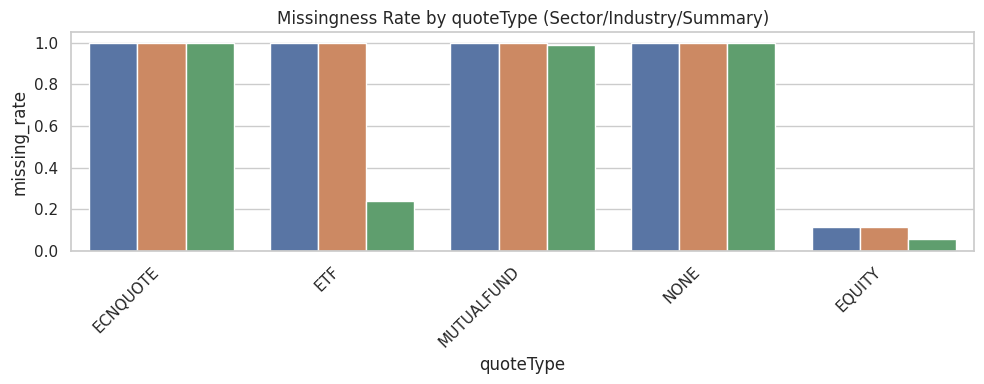

In [4]:
def missing_report(s: pd.Series, name: str):
    s2 = s.copy()
    null_count = int(s2.isna().sum())
    empty_count = int((s2.fillna("").astype(str).str.strip() == "").sum())
    n = len(s2)
    return {
        "field": name,
        "rows": n,
        "null_count": null_count,
        "empty_or_whitespace_count": empty_count,
        "nonempty_count": n - empty_count,
        "pct_null": null_count / n,
        "pct_empty_or_whitespace": empty_count / n,
    }

coverage = pd.DataFrame([
    missing_report(df[sector_col], sector_col),
    missing_report(df[industry_col], industry_col),
    missing_report(df[summary_col], summary_col),
])

display(coverage)
#coverage_path = save_table(coverage, "table_coverage_missingness.csv")
#print("Saved:", coverage_path)

if quote_type_col:
    def is_missing_text(series):
        return series.isna() | (series.astype(str).str.strip() == "")

    tmp = df.copy()
    tmp["_miss_sector"] = is_missing_text(tmp[sector_col])
    tmp["_miss_industry"] = is_missing_text(tmp[industry_col])
    tmp["_miss_summary"] = is_missing_text(tmp[summary_col])

    by_qt = (tmp.groupby(quote_type_col)[["_miss_sector","_miss_industry","_miss_summary"]]
             .mean()
             .sort_values("_miss_sector", ascending=False)
             .reset_index())

    display(by_qt)
    #by_qt_path = save_table(by_qt, "table_missingness_by_quoteType.csv")
    #print("Saved:", by_qt_path)

    plt.figure(figsize=(10,4))
    melted = by_qt.melt(id_vars=quote_type_col, var_name="field", value_name="missing_rate")
    sns.barplot(data=melted, x=quote_type_col, y="missing_rate", hue="field")
    plt.xticks(rotation=45, ha="right")
    plt.title("Missingness Rate by quoteType (Sector/Industry/Summary)")
    plt.tight_layout()
    #fig_path = save_fig("fig_missingness_by_quoteType.png")
    plt.show()
    #print("Saved:", fig_path)

Sector/industry distributions + cross-checks

Unique sectors: 11
Unique industries: 145


,sector,count
0,Financial Services,2014
1,NaN,1812
2,Healthcare,1418
3,Technology,1000
4,Industrials,939
5,Consumer Cyclical,711
6,Basic Materials,607
7,Real Estate,448
8,Communication Services,401
9,Consumer Defensive,381


,industry,count
0,NaN,1812
1,Biotechnology,721
2,Asset Management,569
3,Banks - Regional,484
4,Shell Companies,450
5,Software - Application,320
6,Software - Infrastructure,197
7,Medical Devices,182
8,Other Industrial Metals & Mining,175
9,Drug Manufacturers - Specialty & Generic,163


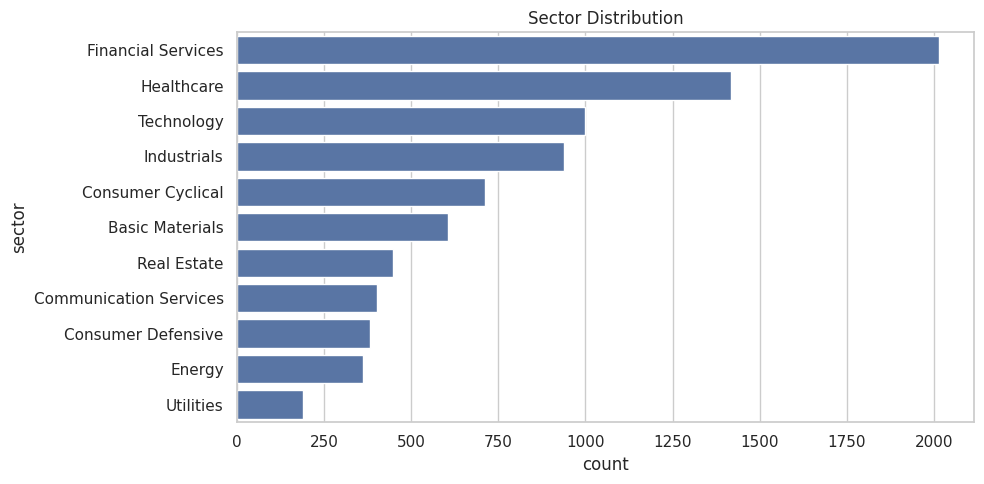

,industry,n_sectors_for_industry
0,Advertising Agencies,1
1,Aerospace & Defense,1
2,Agricultural Inputs,1
3,Airlines,1
4,Airports & Air Services,1
5,Aluminum,1
6,Apparel Manufacturing,1
7,Apparel Retail,1
8,Asset Management,1
9,Auto & Truck Dealerships,1


In [5]:
sector_counts = df[sector_col].value_counts(dropna=False).reset_index()
sector_counts.columns = ["sector", "count"]
industry_counts = df[industry_col].value_counts(dropna=False).reset_index()
industry_counts.columns = ["industry", "count"]

print("Unique sectors:", df[sector_col].nunique(dropna=True))
print("Unique industries:", df[industry_col].nunique(dropna=True))

display(sector_counts.head(20))
display(industry_counts.head(20))

#save_table(sector_counts, "table_sector_counts.csv")
#save_table(industry_counts, "table_industry_counts.csv")

# Plot sector distribution
plt.figure(figsize=(10,5))
top_sector = sector_counts.dropna().head(20)
sns.barplot(data=top_sector, x="count", y="sector")
plt.title("Sector Distribution")
plt.tight_layout()
#fig_path = save_fig("fig_sector_distribution.png")
plt.show()
#print("Saved:", fig_path)

# Industries appearing in multiple sectors (potential label issues)
inds_multi_sector = (df.dropna(subset=[sector_col, industry_col])
                       .groupby(industry_col)[sector_col]
                       .nunique()
                       .sort_values(ascending=False)
                       .reset_index()
                       .rename(columns={sector_col:"n_sectors_for_industry"}))

display(inds_multi_sector.head(30))
#save_table(inds_multi_sector, "table_industries_multi_sector.csv")

 Business summary length profiling (plots + outliers) 

,metric,count,mean,median,p95,p99,max
0,char_len,9181,966.489271,864.0,1944.0,1998.0,5342
1,word_len,9181,133.112624,122.0,254.0,277.0,746
2,sent_len,9181,8.585775,8.0,14.0,18.0,38


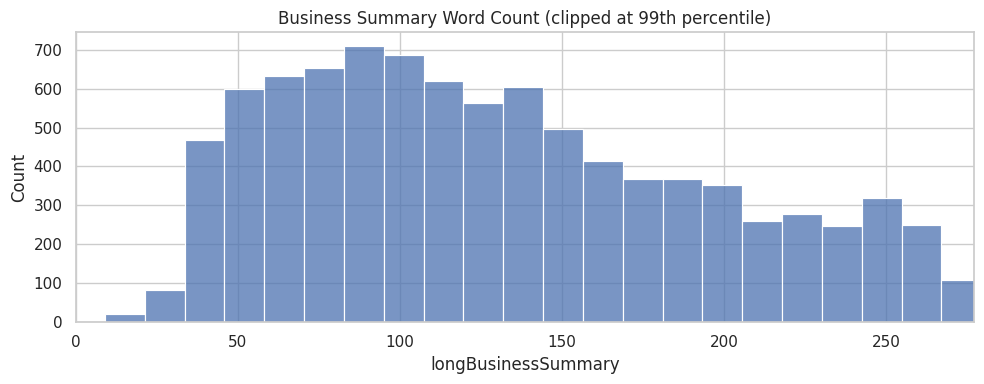

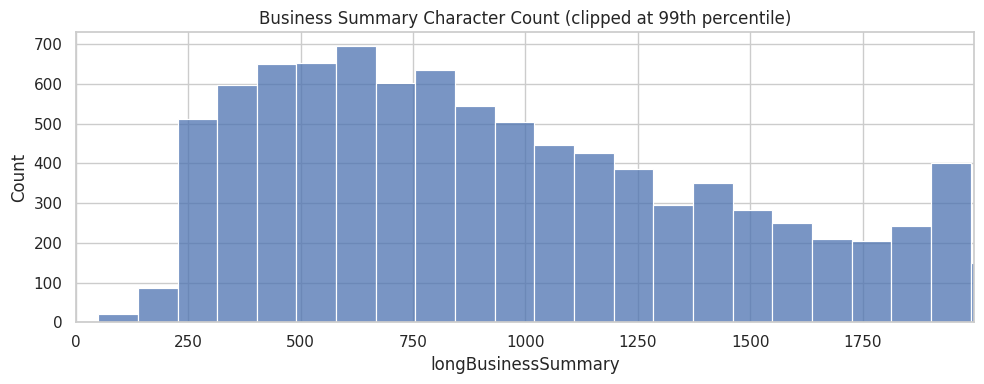

,symbol,company_name,quoteType,sector,industry,longBusinessSummary
3022,MEGI,NYLI CBRE Global Infrastructure Megatrends Term Fund,EQUITY,Financial Services,Asset Management,"NYLI CBRE Global Infrastructure Megatrends Term Fund is headquartered in New York, New York."
3669,XFLT,XAI Octagon Floating Rate & Alternative Income Trust,EQUITY,Financial Services,Asset Management,"XAI Octagon Floating Rate & Alternative Income Trust is headquartered in Chicago, Illinois."
4544,OCCI,"OFS Credit Company, Inc.",EQUITY,Financial Services,Asset Management,"OFS Credit Company, Inc. is a fund of OFS Advisor."
9043,BPYPM,Brookfield Property Partners L.P.,EQUITY,Financial Services,Asset Management,"Brookfield Property Preferred L.P. is headquartered in Hamilton, Bermuda."
9230,OCCIM,"OFS Credit Company, Inc.",EQUITY,Financial Services,Asset Management,"OFS Credit Company, Inc. is a fund of OFS Advisor."
9231,OCCIN,"OFS Credit Company, Inc.",EQUITY,Financial Services,Asset Management,"OFS Credit Company, Inc. is a fund of OFS Advisor."
9232,OCCIO,"OFS Credit Company, Inc.",EQUITY,Financial Services,Asset Management,"OFS Credit Company, Inc. is a fund of OFS Advisor."


In [6]:
summ = df[summary_col].fillna("").astype(str).str.strip()
nonempty = summ[summ != ""]

char_len = nonempty.str.len()
word_len = nonempty.str.split().str.len()
sent_len = nonempty.str.count(r"[.!?]") + 1

length_stats = pd.DataFrame({
    "metric": ["char_len","word_len","sent_len"],
    "count": [len(char_len), len(word_len), len(sent_len)],
    "mean": [char_len.mean(), word_len.mean(), sent_len.mean()],
    "median": [char_len.median(), word_len.median(), sent_len.median()],
    "p95": [char_len.quantile(0.95), word_len.quantile(0.95), sent_len.quantile(0.95)],
    "p99": [char_len.quantile(0.99), word_len.quantile(0.99), sent_len.quantile(0.99)],
    "max": [char_len.max(), word_len.max(), sent_len.max()],
})

display(length_stats)
#save_table(length_stats, "table_summary_length_stats.csv")

# Histograms
plt.figure(figsize=(10,4))
sns.histplot(word_len, bins=60)
plt.xlim(0, np.percentile(word_len, 99))
plt.title("Business Summary Word Count (clipped at 99th percentile)")
plt.tight_layout()
#fig_path = save_fig("fig_summary_wordcount_hist.png")
plt.show()
#print("Saved:", fig_path)

plt.figure(figsize=(10,4))
sns.histplot(char_len, bins=60)
plt.xlim(0, np.percentile(char_len, 99))
plt.title("Business Summary Character Count (clipped at 99th percentile)")
plt.tight_layout()
#fig_path = save_fig("fig_summary_charcount_hist.png")
plt.show()
#print("Saved:", fig_path)

# Very short summaries for inspection
very_short_idx = nonempty.index[word_len < 15]
short_examples = df.loc[very_short_idx, [c for c in [symbol_col, name_col, quote_type_col, sector_col, industry_col, summary_col] if c]].head(20)
display(short_examples)
#save_table(short_examples, "table_very_short_summaries_examples.csv")

— Boilerplate phrase checks + top terms/ngrams 

,phrase,count,pct_of_nonempty
0,headquartered in,5341,0.581745
6,provides,4520,0.492321
1,was founded in,3866,0.421087
2,incorporated in,3768,0.410413
4,engages in,2229,0.242784
3,together with its subsidiaries,1196,0.130269
5,operates in,806,0.087790


,term,count
0,company,20212
1,services,13808
2,products,9931
3,provides,7837
4,offers,7202
5,operates,6089
6,headquartered,5342
7,united,5208
8,solutions,5138
9,management,5011


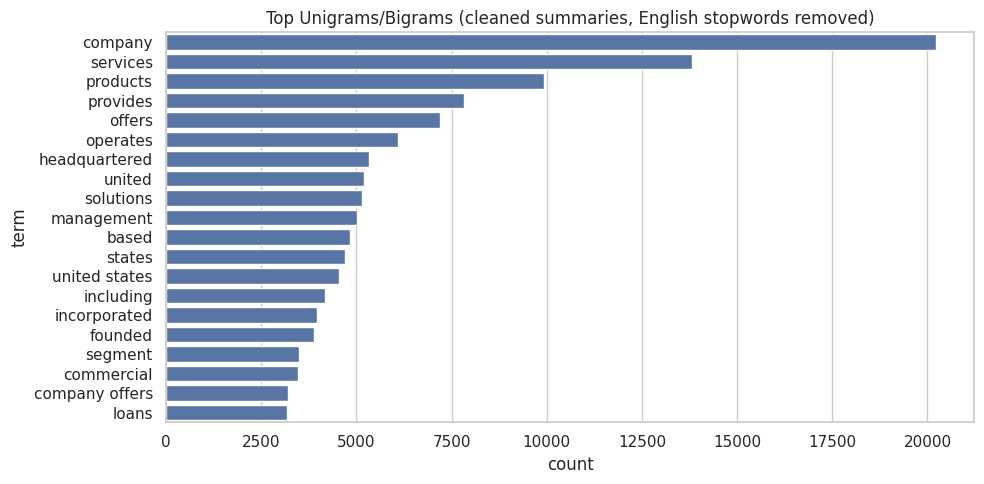

In [7]:
import re

def basic_clean(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_texts = nonempty.map(basic_clean)
summ_lower = nonempty.str.lower()

common_phrases = [
    "headquartered in",
    "was founded in",
    "incorporated in",
    "together with its subsidiaries",
    "engages in",
    "operates in",
    "provides",
]

phrase_freq = pd.DataFrame({
    "phrase": common_phrases,
    "count": [int(summ_lower.str.contains(p).sum()) for p in common_phrases],
})
phrase_freq["pct_of_nonempty"] = phrase_freq["count"] / len(nonempty)
display(phrase_freq.sort_values("count", ascending=False))
#save_table(phrase_freq, "table_common_phrase_freq.csv")

# Top unigrams/bigrams
vec = CountVectorizer(stop_words="english", max_features=60, ngram_range=(1,2))
X = vec.fit_transform(clean_texts)
terms = np.array(vec.get_feature_names_out())
freq = np.asarray(X.sum(axis=0)).ravel()

top_idx = freq.argsort()[::-1][:30]
top_terms = pd.DataFrame({"term": terms[top_idx], "count": freq[top_idx]})
display(top_terms)
#save_table(top_terms, "table_top_terms_ngrams.csv")

plt.figure(figsize=(10,5))
sns.barplot(data=top_terms.head(20), x="count", y="term")
plt.title("Top Unigrams/Bigrams (cleaned summaries, English stopwords removed)")
plt.tight_layout()
#fig_path = save_fig("fig_top_terms_ngrams.png")
plt.show()
#print("Saved:", fig_path)

 Duplicate summaries (exact) + near-duplicates (TF‑IDF)

In [8]:
# Exact duplicates
summary_stripped = df[summary_col].fillna("").astype(str).str.strip()
nonempty_mask = summary_stripped != ""

dup_counts = summary_stripped[nonempty_mask].value_counts()
dup_summary_stats = pd.DataFrame([{
    "distinct_nonempty_summaries": int(dup_counts.shape[0]),
    "distinct_duplicated_summaries": int((dup_counts > 1).sum()),
    "rows_in_duplicated_summaries": int(summary_stripped[nonempty_mask].map(dup_counts).gt(1).sum()),
    "max_repetition_single_summary": int(dup_counts.max())
}])

display(dup_summary_stats)
#save_table(dup_summary_stats, "table_duplicate_summary_stats.csv")

top_dup = dup_counts.head(10).reset_index()
top_dup.columns = ["summary_text", "count"]
top_dup["preview"] = top_dup["summary_text"].str.slice(0, 160) + "..."
display(top_dup[["count","preview"]])
#save_table(top_dup[["count","preview"]], "table_top_duplicated_summaries_preview.csv")

# Near-duplicates with TF-IDF + NearestNeighbors
SAMPLE_N = None  # set e.g. 5000 if you want speed
rng = np.random.default_rng(42)

idx = summary_stripped[nonempty_mask].index.to_numpy()
if SAMPLE_N is not None and SAMPLE_N < len(idx):
    idx = rng.choice(idx, size=SAMPLE_N, replace=False)

texts = df.loc[idx, summary_col].fillna("").astype(str).map(basic_clean)

tfidf = TfidfVectorizer(stop_words="english", min_df=3, max_df=0.90, ngram_range=(1,2))
X = tfidf.fit_transform(texts)

nn = NearestNeighbors(n_neighbors=6, metric="cosine")
nn.fit(X)
dist, neigh = nn.kneighbors(X)

SIM_THRESHOLD = 0.90
pairs = []
for row_i in range(neigh.shape[0]):
    i = idx[row_i]
    for k in range(1, neigh.shape[1]):
        j = idx[neigh[row_i, k]]
        sim = 1 - dist[row_i, k]
        if sim >= SIM_THRESHOLD:
            pairs.append((i, j, sim))

near_dup_df = (pd.DataFrame(pairs, columns=["row_i","row_j","tfidf_cosine_sim"])
               .sort_values("tfidf_cosine_sim", ascending=False))

display(near_dup_df.head(30))
#save_table(near_dup_df.head(500), "table_near_duplicate_pairs_top500.csv")  # cap file size

# add metadata for top pairs
cols_to_show = [c for c in [symbol_col, name_col, quote_type_col, sector_col, industry_col, summary_col] if c]
if len(near_dup_df) > 0 and cols_to_show:
    sample_pairs = near_dup_df.head(20).copy()
    left = df.loc[sample_pairs["row_i"], cols_to_show].reset_index().rename(columns={"index":"row_i"})
    right = df.loc[sample_pairs["row_j"], cols_to_show].reset_index().rename(columns={"index":"row_j"})
    show = sample_pairs.merge(left, on="row_i").merge(right, on="row_j", suffixes=("_A","_B"))
    display(show.head(10))
    #save_table(show.head(50), "table_near_duplicate_pairs_with_metadata_top50.csv")

,distinct_nonempty_summaries,distinct_duplicated_summaries,rows_in_duplicated_summaries,max_repetition_single_summary
0,7628,1044,2597,22


,count,preview
0,22,"Federal Home Loan Mortgage Corporation operates in the secondary mortgage market in the United States. It operates through two segments, Single-Family and Multi..."
1,16,Federal National Mortgage Association provides financing solutions for residential mortgages in the United States. The company operates through Single-Family an...
2,15,"Public Storage, a member of the S&P 500, is a REIT that primarily acquires, develops, owns, and operates self-storage facilities. At September 30, 2025, we: (i)..."
3,15,"Bank of America Corporation, through its subsidiaries, provides various financial products and services for individual consumers, small and middle-market busine..."
4,13,"The Connecticut Light and Power Company, a regulated electric utility, engages in the purchase, delivery, and sale of electricity to residential, commercial, an..."
5,11,"Enbridge Inc., together with its subsidiaries, operates as an energy infrastructure company. The company operates through four segments: Liquids Pipelines, Gas ..."
6,10,"Morgan Stanley, a financial holding company, provides various financial products and services to governments, financial institutions, and individuals in the Ame..."
7,8,"Union Electric Company, doing business as Ameren Missouri, engages in the rate-regulated electric generation, transmission, and distribution business in Missour..."
8,7,"Adamas Trust, Inc. acquires, invests in, finances, and manages mortgage-related single-family and multi-family residential assets in the United States. The comp..."
9,7,Federal Agricultural Mortgage Corporation provides a secondary market for various loans made to borrowers in the United States. It operates through seven segmen...


,row_i,row_j,tfidf_cosine_sim
4745,10283,7494,1.0
0,1,7497,1.0
4743,10276,10276,1.0
2,11,7504,1.0
3,11,7505,1.0
4,11,8365,1.0
5,11,8362,1.0
6,11,8363,1.0
4724,10219,3841,1.0
4723,10215,10215,1.0


,row_i,row_j,tfidf_cosine_sim,symbol_A,company_name_A,quoteType_A,sector_A,industry_A,longBusinessSummary_A,symbol_B,company_name_B,quoteType_B,sector_B,industry_B,longBusinessSummary_B
0,10283,7494,1.0,MTPLF,Metaplanet Inc.,EQUITY,Consumer Cyclical,Restaurants,Metaplanet Inc. engages in hotel management operation and development in Japan. The company operates through Hotel Business and Bitcoin Treasury Business segments. It is also i...,MPJPY,Metaplanet Inc.,EQUITY,NaN,NaN,Metaplanet Inc. engages in hotel management operation and development in Japan. The company operates through Hotel Business and Bitcoin Treasury Business segments. It is also i...
1,1,7497,1.0,GOOGL,Alphabet Inc.,EQUITY,Communication Services,Internet Content & Information,"Alphabet Inc. offers various products and platforms in the United States, Europe, the Middle East, Africa, the Asia-Pacific, Canada, and Latin America. It operates through Goog...",GOOG,Alphabet Inc.,EQUITY,Communication Services,Internet Content & Information,"Alphabet Inc. offers various products and platforms in the United States, Europe, the Middle East, Africa, the Asia-Pacific, Canada, and Latin America. It operates through Goog..."
2,10276,10276,1.0,MAWAF,"Maruwa Co., Ltd./ADR",EQUITY,Technology,Electronic Components,"Maruwa Co.,Ltd. produces and sells ceramics and electronic parts in Japan and internationally. The Company has two reportable segments: Lamic Components Business, and Lighting ...",MAWAF,"Maruwa Co., Ltd./ADR",EQUITY,Technology,Electronic Components,"Maruwa Co.,Ltd. produces and sells ceramics and electronic parts in Japan and internationally. The Company has two reportable segments: Lamic Components Business, and Lighting ..."
3,11,7504,1.0,JPM,JPMORGAN CHASE & CO,EQUITY,Financial Services,Banks - Diversified,"JPMorgan Chase & Co. operates as a financial services company worldwide. It operates through three segments: Consumer & Community Banking, Commercial & Investment Bank, and Ass...",JPM-PC,JPMORGAN CHASE & CO,EQUITY,Financial Services,Banks - Diversified,"JPMorgan Chase & Co. operates as a financial services company worldwide. It operates through three segments: Consumer & Community Banking, Commercial & Investment Bank, and Ass..."
4,11,7504,1.0,JPM,JPMORGAN CHASE & CO,EQUITY,Financial Services,Banks - Diversified,"JPMorgan Chase & Co. operates as a financial services company worldwide. It operates through three segments: Consumer & Community Banking, Commercial & Investment Bank, and Ass...",JPM-PC,JPMORGAN CHASE & CO,EQUITY,Financial Services,Banks - Diversified,"JPMorgan Chase & Co. operates as a financial services company worldwide. It operates through three segments: Consumer & Community Banking, Commercial & Investment Bank, and Ass..."
5,11,7504,1.0,JPM,JPMORGAN CHASE & CO,EQUITY,Financial Services,Banks - Diversified,"JPMorgan Chase & Co. operates as a financial services company worldwide. It operates through three segments: Consumer & Community Banking, Commercial & Investment Bank, and Ass...",JPM-PC,JPMORGAN CHASE & CO,EQUITY,Financial Services,Banks - Diversified,"JPMorgan Chase & Co. operates as a financial services company worldwide. It operates through three segments: Consumer & Community Banking, Commercial & Investment Bank, and Ass..."
6,11,7504,1.0,JPM,JPMORGAN CHASE & CO,EQUITY,Financial Services,Banks - Diversified,"JPMorgan Chase & Co. operates as a financial services company worldwide. It operates through three segments: Consumer & Community Banking, Commercial & Investment Bank, and Ass...",JPM-PC,JPMORGAN CHASE & CO,EQUITY,Financial Services,Banks - Diversified,"JPMorgan Chase & Co. operates as a financial services company worldwide. It operates through three segments: Consumer & Community Banking, Commercial & Investment Bank, and Ass..."
7,11,7504,1.0,JPM,JPMORGAN CHASE & CO,EQUITY,Financial Services,Banks - Diversified,"JPMorgan Chase & Co. operates as a financial services company worldwide. It operates through three segments: Consu

 Build the “embed_text” 

In [9]:
def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def build_embed_text(row):
    parts = []
    if safe_str(row[sector_col]):
        parts.append(f"Sector: {safe_str(row[sector_col])}")
    if safe_str(row[industry_col]):
        parts.append(f"Industry: {safe_str(row[industry_col])}")
    if safe_str(row[summary_col]):
        parts.append(f"Summary: {safe_str(row[summary_col])}")
    return " | ".join(parts).strip()

df["embed_text"] = df.apply(build_embed_text, axis=1)
df["embed_text_is_empty"] = df["embed_text"].str.strip().eq("")

embed_ready_stats = pd.DataFrame([{
    "rows_total": len(df),
    "rows_embed_text_empty": int(df["embed_text_is_empty"].sum()),
    "rows_embed_text_nonempty": int((~df["embed_text_is_empty"]).sum())
}])

display(embed_ready_stats)
#save_table(embed_ready_stats, "table_embed_text_readiness.csv")

# Save a modeling-ready subset file (keeps key fields + embed_text)
keep_cols = [c for c in [symbol_col, name_col, quote_type_col, sector_col, industry_col, summary_col, "embed_text"] if c in df.columns]
model_df = df.loc[~df["embed_text_is_empty"], keep_cols].copy()
#model_path = OUTDIR / "modeling_ready_text.csv"
#model_df.to_csv(model_path, index=False)
#print("Saved:", model_path)

,rows_total,rows_embed_text_empty,rows_embed_text_nonempty
0,10284,1071,9213


In [ ]:
# 4) Check what changed
!git status -sb

# 5) Stage + commit
#!git add -A
#!git commit -m "push jupyter hub changes"

# 6) Push
#!git push

## main...origin/main
?? outputs/
[main 9ee0a3a] push jupyter hub changes
 2 files changed, 10299 insertions(+)
 create mode 100644 outputs/_extracted/stock_symbols_new.csv
 create mode 100644 outputs/table_missingness_by_quoteType.csv
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 4 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (6/6), 9.18 MiB | 4.51 MiB/s, done.
Total 6 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/tongyuguo/HelpHerInvest.git
   24599e3..9ee0a3a  main -> main


report 

In [11]:
'''

def pct(a, b):
    return (a / b) if b else np.nan

n_rows = len(df)
miss_sector = int(df[sector_col].isna().sum())
miss_industry = int(df[industry_col].isna().sum())
miss_summary = int(df[summary_col].isna().sum())

median_words = float(word_len.median()) if len(word_len) else np.nan
p95_words = float(word_len.quantile(0.95)) if len(word_len) else np.nan
max_words = int(word_len.max()) if len(word_len) else np.nan

dup_distinct = int(dup_summary_stats.loc[0, "distinct_duplicated_summaries"])
dup_rows = int(dup_summary_stats.loc[0, "rows_in_duplicated_summaries"])
max_rep = int(dup_summary_stats.loc[0, "max_repetition_single_summary"])

report_lines = []
report_lines.append("# NLP EDA Report Appendix\n")
report_lines.append(f"Generated: {datetime.now().isoformat(timespec='seconds')}\n")
report_lines.append("## Problem Context (Week 1)\n")
report_lines.append(
    "This project aims to reduce the barrier for beginner investors by translating user preferences into personalized stock recommendations "
    "using NLP similarity on sector, industry, and business description text.\n"
)

report_lines.append("## Dataset Overview\n")
report_lines.append(f"- Rows: **{n_rows:,}**\n")
report_lines.append(f"- Columns: **{df.shape[1]:,}**\n")
report_lines.append(f"- NLP fields used: `{sector_col}`, `{industry_col}`, `{summary_col}`\n\n")

report_lines.append("## 1) Coverage / Missingness\n")
report_lines.append(f"- Missing `{sector_col}`: **{miss_sector:,}** ({pct(miss_sector,n_rows):.1%})\n")
report_lines.append(f"- Missing `{industry_col}`: **{miss_industry:,}** ({pct(miss_industry,n_rows):.1%})\n")
report_lines.append(f"- Missing `{summary_col}`: **{miss_summary:,}** ({pct(miss_summary,n_rows):.1%})\n\n")
report_lines.append(f"Tables: `table_coverage_missingness.csv`, `table_missingness_by_quoteType.csv`\n")
report_lines.append(f"Figure: `fig_missingness_by_quoteType.png`\n\n")

report_lines.append("## 2) Sector / Industry Distributions\n")
report_lines.append(f"- Unique sectors: **{df[sector_col].nunique(dropna=True)}**\n")
report_lines.append(f"- Unique industries: **{df[industry_col].nunique(dropna=True)}**\n\n")
report_lines.append("Tables: `table_sector_counts.csv`, `table_industry_counts.csv`, `table_industries_multi_sector.csv`\n")
report_lines.append("Figure: `fig_sector_distribution.png`\n\n")

report_lines.append("## 3) Business Summary Length (Embedding Readiness)\n")
report_lines.append(f"- Median word count: **{median_words:.0f}**\n")
report_lines.append(f"- 95th percentile word count: **{p95_words:.0f}**\n")
report_lines.append(f"- Max word count: **{max_words}**\n\n")
report_lines.append("Tables: `table_summary_length_stats.csv`, `table_very_short_summaries_examples.csv`\n")
report_lines.append("Figures: `fig_summary_wordcount_hist.png`, `fig_summary_charcount_hist.png`\n\n")

report_lines.append("## 4) Boilerplate / Template Language\n")
report_lines.append(
    "Many business summaries include repeated corporate boilerplate (e.g., 'headquartered in', 'together with its subsidiaries'), "
    "which can reduce discriminative power in embedding similarity.\n\n"
)
report_lines.append("Tables: `table_common_phrase_freq.csv`, `table_top_terms_ngrams.csv`\n")
report_lines.append("Figure: `fig_top_terms_ngrams.png`\n\n")

report_lines.append("## 5) Duplicate and Near-Duplicate Summaries\n")
report_lines.append(f"- Distinct duplicated summaries (exact): **{dup_distinct:,}**\n")
report_lines.append(f"- Rows in duplicated summaries: **{dup_rows:,}**\n")
report_lines.append(f"- Max repetition of a single summary: **{max_rep}**\n\n")
report_lines.append("Tables: `table_duplicate_summary_stats.csv`, `table_top_duplicated_summaries_preview.csv`, `table_near_duplicate_pairs_top500.csv`\n\n")

report_lines.append("## Key Insights (Opportunities & Challenges)\n")
report_lines.append(
    "### Opportunities\n"
    "- Sector/industry labels provide interpretable metadata that can be used both for ranking and for explaining recommendations to beginners.\n"
    "- Most equity-like rows contain paragraph-length summaries suitable for semantic matching.\n\n"
    "### Challenges\n"
    "- Missingness is not random and tends to cluster by instrument type; scoring will be inconsistent unless you filter to equities or implement fallbacks.\n"
    "- Exact/near-duplicate summaries can cause repetitive top-N outputs (e.g., multiple share classes), which is confusing in a beginner-focused UX.\n"
    "- Boilerplate-heavy language may cause weaker relevance to user intent unless cleaned or downweighted.\n\n"
)

report_lines.append("## Recommendations (Preprocessing)\n")
report_lines.append(
    "1) **Filter MVP to equities** (e.g., `quoteType == 'EQUITY'`) or build separate pipelines by instrument type.\n"
    "2) **Normalize** sector/industry strings (trim whitespace; unify hyphen spacing; choose one canonical field).\n"
    "3) Apply **light text cleaning** (whitespace normalization; optional custom boilerplate stopphrases).\n"
    "4) **Truncate summaries consistently** (first N words/sentences) to control embedding behavior.\n"
    "5) Add **deduplication/diversification** logic so top-N recommendations are not dominated by the same issuer.\n"
)

report_path = OUTDIR / "NLP_EDA_Report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")
print("Wrote report:", report_path)

'''

'\n\ndef pct(a, b):\n    return (a / b) if b else np.nan\n\nn_rows = len(df)\nmiss_sector = int(df[sector_col].isna().sum())\nmiss_industry = int(df[industry_col].isna().sum())\nmiss_summary = int(df[summary_col].isna().sum())\n\nmedian_words = float(word_len.median()) if len(word_len) else np.nan\np95_words = float(word_len.quantile(0.95)) if len(word_len) else np.nan\nmax_words = int(word_len.max()) if len(word_len) else np.nan\n\ndup_distinct = int(dup_summary_stats.loc[0, "distinct_duplicated_summaries"])\ndup_rows = int(dup_summary_stats.loc[0, "rows_in_duplicated_summaries"])\nmax_rep = int(dup_summary_stats.loc[0, "max_repetition_single_summary"])\n\nreport_lines = []\nreport_lines.append("# NLP EDA Report Appendix\n")\nreport_lines.append(f"Generated: {datetime.now().isoformat(timespec=\'seconds\')}\n")\nreport_lines.append("## Problem Context (Week 1)\n")\nreport_lines.append(\n    "This project aims to reduce the barrier for beginner investors by translating user preferences 